<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week04_entanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Multi-qubit circuits: Entanglement

In [ ]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pylatexenc

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

**1. Create an *entangled* Bell state**

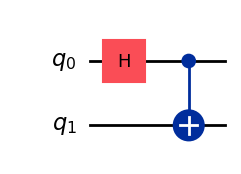

In [ ]:
def create_bell_state():
    qc = QuantumCircuit(2)

    # Step 1: Apply Hadamard to first qubit
    qc.h(0)
    # Step 2: Apply CNOT with qubit 0 as control, qubit 1 as target
    qc.cx(0, 1)
    return qc
bell_circuit = create_bell_state()
bell_circuit.draw(output='mpl')

**2. Create a *non-entangled* (separable) state**

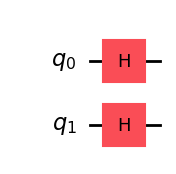

In [ ]:
def create_separable_state():
    qc = QuantumCircuit(2)
    # Apply Hadamard to first qubit
    qc.h(0)
    # Apply Hadamard to second qubit
    qc.h(1)
    return qc
separable_circuit = create_separable_state()
separable_circuit.draw(output='mpl')

**3. Measurement outcomes for both circuits**

In [ ]:
# Add measurements to both circuits
bell_measured = bell_circuit.copy()
bell_measured.measure_all()

separable_measured = separable_circuit.copy()
separable_measured.measure_all()

# Run simulations
simulator = AerSimulator()
shots = 1000

bell_job = simulator.run(bell_measured, shots=shots)
bell_counts = bell_job.result().get_counts()

separable_job = simulator.run(separable_measured, shots=shots)
separable_counts = separable_job.result().get_counts()

print(f"Bell State measurements ({shots} shots):")
print(bell_counts)
print(f"\nSeparable State measurements ({shots} shots):")
print(separable_counts)

Bell State measurements (1000 shots):
{'00': 525, '11': 475}

Separable State measurements (1000 shots):
{'11': 251, '01': 236, '00': 244, '10': 269}
